In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_util = pd.read_csv("../data/processed/utilization_clean.csv")
df_growth = pd.read_csv("../data/processed/growth_clean.csv")
df_assets = pd.read_csv("../data/processed/assets_clean.csv")

df_util["Record_Date"] = pd.to_datetime(df_util["Record_Date"])

print("Assets loaded:", df_assets.shape)
print("Utilization loaded:", df_util.shape)
print("Growth loaded:", df_growth.shape)

Assets loaded: (85, 9)
Utilization loaded: (1530, 8)
Growth loaded: (35, 3)


In [3]:
growth_rates = {}

for device_type in df_growth["Device_Type"].unique():
    data = df_growth[df_growth["Device_Type"] == device_type].sort_values("Year")
    yearly_changes = data["Device_Count"].pct_change().dropna()
    avg_growth_rate = yearly_changes.mean()
    growth_rates[device_type] = avg_growth_rate

for device_type, rate in growth_rates.items():
    print(f"{device_type}: {round(rate * 100, 2)}% average yearly growth")

Router: 12.66% average yearly growth
Switch: 16.95% average yearly growth
Access Point: 32.06% average yearly growth
Firewall: 18.06% average yearly growth
Server: 15.84% average yearly growth


In [5]:
forecast_years = [2027, 2028, 2029]
forecast_data = []

for device_type, rate in growth_rates.items():
    current_count = df_growth[df_growth["Device_Type"] == device_type]["Device_Count"].iloc[-1]
    for year in forecast_years:
        years_ahead = year - 2026
        forecasted_count = round(current_count * ((1 + rate) ** years_ahead))
        forecast_data.append({
            "Device_Type": device_type,
            "Year": year,
            "Forecasted_Count": forecasted_count
        })

df_forecast = pd.DataFrame(forecast_data)
print(df_forecast)

     Device_Type  Year  Forecasted_Count
0         Router  2027                 9
1         Router  2028                10
2         Router  2029                11
3         Switch  2027                23
4         Switch  2028                27
5         Switch  2029                32
6   Access Point  2027               125
7   Access Point  2028               166
8   Access Point  2029               219
9       Firewall  2027                 6
10      Firewall  2028                 7
11      Firewall  2029                 8
12        Server  2027                14
13        Server  2028                16
14        Server  2029                19


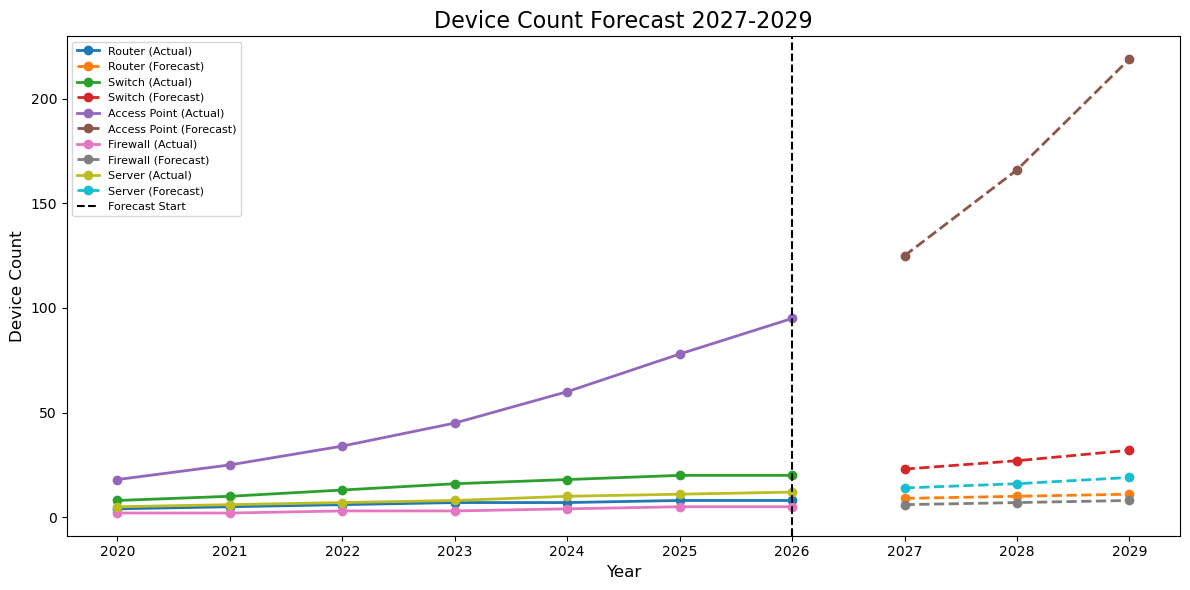

In [7]:
plt.figure(figsize=(12, 6))

for device_type in df_growth["Device_Type"].unique():
    # Historical data
    historical = df_growth[df_growth["Device_Type"] == device_type]
    plt.plot(historical["Year"], historical["Device_Count"], 
             marker="o", linewidth=2, label=f"{device_type} (Actual)")
    
    # Forecast data
    forecast = df_forecast[df_forecast["Device_Type"] == device_type]
    plt.plot(forecast["Year"], forecast["Forecasted_Count"], 
             marker="o", linewidth=2, linestyle="--", label=f"{device_type} (Forecast)")

plt.axvline(x=2026, color="black", linestyle="--", linewidth=1.5, label="Forecast Start")
plt.title("Device Count Forecast 2027-2029", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Device Count", fontsize=12)
plt.legend(loc="upper left", fontsize=8)
plt.xticks([2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029])
plt.tight_layout()
plt.savefig("../data/processed/device_forecast.png")
plt.show()

In [9]:
# Define thresholds
CPU_THRESHOLD = 75
MEMORY_THRESHOLD = 75
BANDWIDTH_THRESHOLD = 75

# Get latest month's data
latest_date = df_util["Record_Date"].max()
latest_util = df_util[df_util["Record_Date"] == latest_date]

# Find high utilization devices
high_cpu = latest_util[latest_util["CPU_Utilization_Pct"] >= CPU_THRESHOLD]
high_memory = latest_util[latest_util["Memory_Utilization_Pct"] >= MEMORY_THRESHOLD]
high_bandwidth = latest_util[latest_util["Bandwidth_Utilization_Pct"] >= BANDWIDTH_THRESHOLD]

print(f"Latest data date: {latest_date.date()}")
print(f"\nDevices with HIGH CPU (>= {CPU_THRESHOLD}%):       {len(high_cpu)}")
print(f"Devices with HIGH Memory (>= {MEMORY_THRESHOLD}%):    {len(high_memory)}")
print(f"Devices with HIGH Bandwidth (>= {BANDWIDTH_THRESHOLD}%): {len(high_bandwidth)}")

Latest data date: 2026-05-26

Devices with HIGH CPU (>= 75%):       4
Devices with HIGH Memory (>= 75%):    8
Devices with HIGH Bandwidth (>= 75%): 5


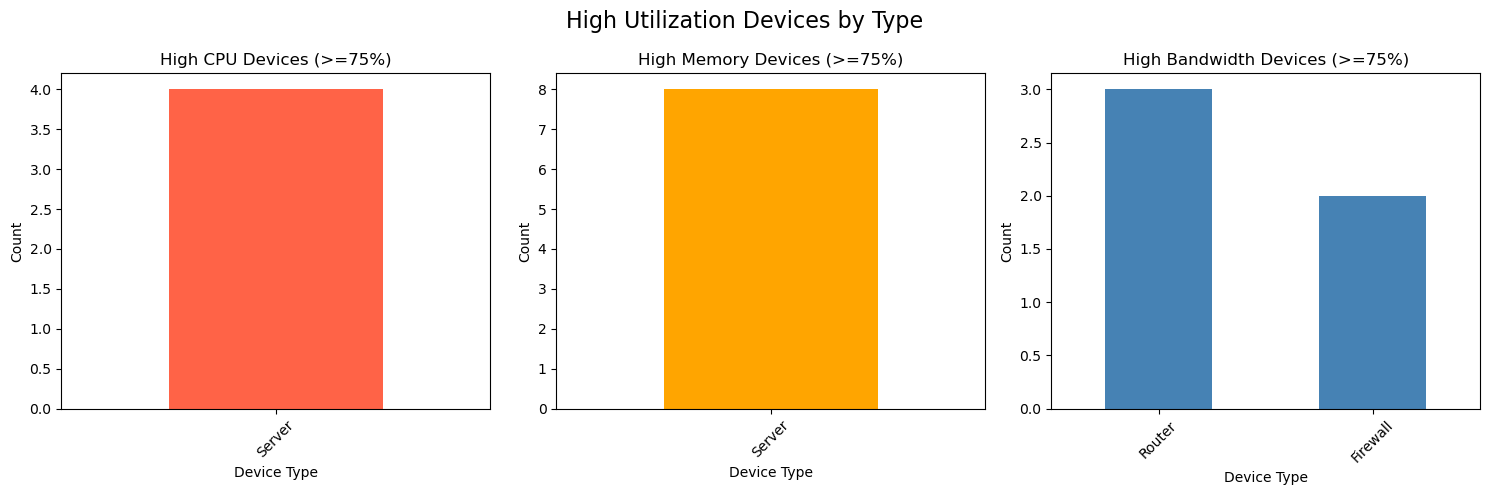

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CPU
high_cpu["Device_Type"].value_counts().plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title(f"High CPU Devices (>={CPU_THRESHOLD}%)", fontsize=12)
axes[0].set_xlabel("Device Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Memory
high_memory["Device_Type"].value_counts().plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title(f"High Memory Devices (>={MEMORY_THRESHOLD}%)", fontsize=12)
axes[1].set_xlabel("Device Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

# Bandwidth
high_bandwidth["Device_Type"].value_counts().plot(kind="bar", ax=axes[2], color="steelblue")
axes[2].set_title(f"High Bandwidth Devices (>={BANDWIDTH_THRESHOLD}%)", fontsize=12)
axes[2].set_xlabel("Device Type")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("High Utilization Devices by Type", fontsize=16)
plt.tight_layout()
plt.savefig("../data/processed/high_utilization_devices.png")
plt.show()

In [13]:
recommendations = []

# Check high CPU devices
for _, row in high_cpu.iterrows():
    recommendations.append({
        "Asset_ID": row["Asset_ID"],
        "Device_Type": row["Device_Type"],
        "Issue": "High CPU Utilization",
        "Current_Value": f"{row['CPU_Utilization_Pct']}%",
        "Recommendation": "Upgrade processor or redistribute workload"
    })

# Check high memory devices
for _, row in high_memory.iterrows():
    recommendations.append({
        "Asset_ID": row["Asset_ID"],
        "Device_Type": row["Device_Type"],
        "Issue": "High Memory Utilization",
        "Current_Value": f"{row['Memory_Utilization_Pct']}%",
        "Recommendation": "Upgrade RAM or optimize memory usage"
    })

# Check high bandwidth devices
for _, row in high_bandwidth.iterrows():
    recommendations.append({
        "Asset_ID": row["Asset_ID"],
        "Device_Type": row["Device_Type"],
        "Issue": "High Bandwidth Utilization",
        "Current_Value": f"{row['Bandwidth_Utilization_Pct']}%",
        "Recommendation": "Upgrade bandwidth capacity or add new device"
    })

df_recommendations = pd.DataFrame(recommendations)
print(f"Total recommendations generated: {len(df_recommendations)}")
print("\n")
print(df_recommendations)

Total recommendations generated: 17


    Asset_ID Device_Type                       Issue Current_Value  \
0   AST-1074      Server        High CPU Utilization        76.24%   
1   AST-1075      Server        High CPU Utilization        75.99%   
2   AST-1077      Server        High CPU Utilization         80.7%   
3   AST-1083      Server        High CPU Utilization        78.27%   
4   AST-1074      Server     High Memory Utilization        89.62%   
5   AST-1075      Server     High Memory Utilization        78.26%   
6   AST-1076      Server     High Memory Utilization        88.88%   
7   AST-1077      Server     High Memory Utilization        79.74%   
8   AST-1078      Server     High Memory Utilization        78.71%   
9   AST-1079      Server     High Memory Utilization         75.5%   
10  AST-1082      Server     High Memory Utilization        79.31%   
11  AST-1085      Server     High Memory Utilization        81.21%   
12  AST-1003      Router  High Bandwidth Utilization

In [15]:
df_recommendations.to_csv("../data/processed/upgrade_recommendations.csv", index=False)
print("Recommendations saved successfully!")

Recommendations saved successfully!


In [17]:
print("=" * 55)
print("        CAPACITY FORECASTING SUMMARY")
print("=" * 55)

print(f"\nCurrent Network Size (2026):")
for device_type in df_growth["Device_Type"].unique():
    current = df_growth[df_growth["Device_Type"] == device_type]["Device_Count"].iloc[-1]
    print(f"  {device_type:<20} {current} devices")

print(f"\nForecasted Network Size (2029):")
for device_type in df_growth["Device_Type"].unique():
    forecasted = df_forecast[(df_forecast["Device_Type"] == device_type) & 
                             (df_forecast["Year"] == 2029)]["Forecasted_Count"].values[0]
    print(f"  {device_type:<20} {forecasted} devices")

print(f"\nHigh Utilization Alerts (as of {latest_date.date()}):")
print(f"  High CPU Devices:        {len(high_cpu)}")
print(f"  High Memory Devices:     {len(high_memory)}")
print(f"  High Bandwidth Devices:  {len(high_bandwidth)}")

print(f"\nTotal Upgrade Recommendations: {len(df_recommendations)}")
print("=" * 55)

        CAPACITY FORECASTING SUMMARY

Current Network Size (2026):
  Router               8 devices
  Switch               20 devices
  Access Point         95 devices
  Firewall             5 devices
  Server               12 devices

Forecasted Network Size (2029):
  Router               11 devices
  Switch               32 devices
  Access Point         219 devices
  Firewall             8 devices
  Server               19 devices

High Utilization Alerts (as of 2026-05-26):
  High CPU Devices:        4
  High Memory Devices:     8
  High Bandwidth Devices:  5

Total Upgrade Recommendations: 17
